In [2]:
import matplotlib.pyplot as plt
import numpy as np

ORTHOGONAL_DIRECTIONS = [(-1, 0), (1, 0), (0, -1), (0, 1)]  # No diagonals

def parse_board(board_str):
    """Convert board string to a 2D list representation and validate legality."""
    rows = board_str.split("|")
    row_lengths = {len(row) for row in rows}  # Get unique row lengths

    # Rule 1: All rows must have the same length
    if len(row_lengths) > 1:
        raise ValueError("Invalid board: Rows must all be the same length.")

    # Rule 2: Check for invalid characters
    allowed_chars = {"O", "X", "*"}
    for row in rows:
        if not set(row).issubset(allowed_chars):
            raise ValueError("Invalid board: Only 'O', 'X', and '*' are allowed.")

    # Rule 3: There must be at least one "O" and one "X"
    board_flat = "".join(rows)
    # if "O" not in board_flat or "X" not in board_flat:
    #     raise ValueError("Invalid board: Must contain at least one 'O' and one 'X'.")

    return [list(row) for row in rows]  # Convert to 2D list
    
def display_board(board):
    """Print the board in a readable format."""
    for row in board:
        print(" ".join(map(str, row)))  # Ensure everything is a string
    print()

def get_groups(board, player):
    """Find all groups (connected components) of the given player."""
    groups = []
    visited = set()
    rows, cols = len(board), len(board[0])

    def dfs(r, c, group):
        """Depth-first search to collect connected pieces."""
        if (r, c) in visited or board[r][c] != player:
            return
        visited.add((r, c))
        group.append((r, c))
        for dr, dc in ORTHOGONAL_DIRECTIONS:
            nr, nc = r + dr, c + dc
            if 0 <= nr < rows and 0 <= nc < cols:
                dfs(nr, nc, group)

    for r in range(rows):
        for c in range(cols):
            if board[r][c] == player and (r, c) not in visited:
                group = []
                dfs(r, c, group)
                groups.append(group)
    
    return groups

def get_valid_moves(board, group):
    """Get all empty spaces orthogonally adjacent to a group."""
    rows, cols = len(board), len(board[0])
    moves = set()

    for r, c in group:
        for dr, dc in ORTHOGONAL_DIRECTIONS:
            nr, nc = r + dr, c + dc
            if 0 <= nr < rows and 0 <= nc < cols and board[nr][nc] == "*":
                moves.add((nr, nc))
    
    return list(moves)

def highlight_moves(board, moves):
    """Display the board with move options."""
    temp_board = [row[:] for row in board]  # Copy board
    for i, (r, c) in enumerate(moves, start=1):
        temp_board[r][c] = str(i)  # Mark valid moves as numbers
    display_board(temp_board)

def apply_move(board, group):
    """Expand the selected group into all adjacent valid move positions."""
    player = board[group[0][0]][group[0][1]]  # Get player's symbol
    move_positions = get_valid_moves(board, group)

    for r, c in move_positions:
        board[r][c] = player  # Convert empty spaces to player's symbol

def has_moves(board, player):
    """Check if a player has any valid moves left."""
    groups = get_groups(board, player)
    for group in groups:
        if get_valid_moves(board, group):
            return True
    return False

def play_game(board_str):
    """Main game loop."""
    board = parse_board(board_str)
    # display_board(board)
    visualize_board_array(board)
    players = ["O", "X"]
    turn = 0  # O starts

    while True:
        current_player = players[turn]
        print(f"Player {current_player}'s turn:")
        
        groups = get_groups(board, current_player)
        valid_moves = []

        # Collect all valid moves for each group
        for group in groups:
            moves = get_valid_moves(board, group)
            if moves:
                valid_moves.append((group, moves))
        
        if not valid_moves:
            print(f"Player {current_player} has no moves left! {players[1-turn]} wins!")
            break  # Game over

        # Show available moves
        for i, (group, moves) in enumerate(valid_moves, start=1):
            print(f"{i}. Group at {group} → Expand to {moves}")

        while True:  # Keep asking until a valid move is chosen
            try:
                choice = int(input("Choose a group (1, 2, ...): ")) - 1
                if 0 <= choice < len(valid_moves):
                    break  # Exit loop if the choice is valid
                elif choice ==-1:
                    break
                else:
                    print(f"Invalid choice! Please enter a number between 0 and {len(valid_moves) - 1}.")
            except ValueError:
                print("Invalid input! Please enter a valid integer.")
        if choice==-1:
            print("why end so fast :(")
            break
        if 0 <= choice < len(valid_moves):
            chosen_group, _ = valid_moves[choice]

            # Expand into all valid adjacent spaces
            apply_move(board, chosen_group)
        
        # Show updated board
        # display_board(board)
        visualize_board_array(board)
        turn = 1 - turn  # Switch players

import matplotlib.pyplot as plt
import numpy as np


# Example Board Visualization
# visualize_board("OX**|****|XO**")

# Example Game Start

# Example Board Visualization
# visualize_board("OX**|****|XO**")

In [3]:
def visualize_board(board_str, move=None):
    """
    Visualize the board using Matplotlib with circular beads for pieces.
    Optionally highlight a move.
    
    Parameters:
    - board_str: String representation of the board
    - move: Optional tuple (group, moves) indicating the move to highlight
    """
    board = [list(row) for row in board_str.split("|")]
    rows, cols = len(board), len(board[0])
    color_map = {"O": "blue", "X": "red", "*": "white"}

    fig, ax = plt.subplots(figsize=(cols * 0.5, rows * 0.5))  # Smaller overall figure
    
    # Fixing grid line positions
    ax.set_xticks(np.arange(0, cols + 1, 1))  # cols + 1 to fully enclose
    ax.set_yticks(np.arange(0, rows + 1, 1))  # rows + 1 to fully enclose
    ax.grid(which="both", color="black", linestyle='-', linewidth=1)
    ax.set_xticklabels([])
    ax.set_yticklabels([])
    ax.tick_params(which="both", bottom=False, left=False)

    # Extract move information
    move_group = []
    move_cells = []
    if move is not None:
        group, cells = move
        move_group = group
        move_cells = cells

    # Draw grid squares with yellow background for the move
    for r in range(rows):
        for c in range(cols):
            cell_color = "white"
            if (r, c) in move_cells:
                cell_color = "yellow"  # Move cells in yellow
            ax.add_patch(plt.Rectangle((c, rows - r - 1), 1, 1, edgecolor="black", facecolor=cell_color))

    # Draw circular beads for pieces
    for r in range(rows):
        for c in range(cols):
            if board[r][c] in color_map and board[r][c] != "*":
                ax.add_patch(plt.Circle((c + 0.5, rows - r - 0.5), 0.3, color=color_map[board[r][c]], ec="black"))

    plt.show()

def visualize_board_array(board, move=None):
    """
    Visualize the board array using Matplotlib with circular beads for pieces.
    Optionally highlight a move.
    
    Parameters:
    - board: Array representation of the board
    - move: Optional tuple (group, moves) indicating the move to highlight
    """
    rows, cols = len(board), len(board[0])
    color_map = {"O": "blue", "X": "red", "*": "white"}

    fig, ax = plt.subplots(figsize=(cols * 0.5, rows * 0.5))  # Smaller overall figure
    
    # Fixing grid line positions
    ax.set_xticks(np.arange(0, cols + 1, 1))  # cols + 1 to fully enclose
    ax.set_yticks(np.arange(0, rows + 1, 1))  # rows + 1 to fully enclose
    ax.grid(which="both", color="black", linestyle='-', linewidth=1)
    ax.set_xticklabels([])
    ax.set_yticklabels([])
    ax.tick_params(which="both", bottom=False, left=False)

    # Extract move information
    move_group = []
    move_cells = []
    if move is not None:
        group, cells = move
        move_group = group
        move_cells = cells

    # Draw grid squares with yellow background for the move
    for r in range(rows):
        for c in range(cols):
            cell_color = "white"
            if (r, c) in move_cells:
                cell_color = "yellow"  # Move cells in yellow
            ax.add_patch(plt.Rectangle((c, rows - r - 1), 1, 1, edgecolor="black", facecolor=cell_color))

    # Draw circular beads for pieces
    for r in range(rows):
        for c in range(cols):
            if board[r][c] in color_map and board[r][c] != "*":
                ax.add_patch(plt.Circle((c + 0.5, rows - r - 0.5), 0.3, color=color_map[board[r][c]], ec="black"))

    plt.show()


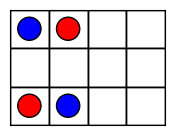

In [4]:
import matplotlib.pyplot as plt
import numpy as np

def visualize_board_array(board):
    """Visualize the board using Matplotlib with circular beads for pieces."""
    rows, cols = len(board), len(board[0])
    color_map = {"O": "blue", "X": "red", "*": "white"}

    # fig, ax = plt.subplots(figsize=(cols, rows))
    fig, ax = plt.subplots(figsize=(cols * 0.5, rows * 0.5))  # Smaller overall figure

    # Fixing grid line positions
    ax.set_xticks(np.arange(0, cols + 1, 1))  # cols + 1 to fully enclose
    ax.set_yticks(np.arange(0, rows + 1, 1))  # rows + 1 to fully enclose
    ax.grid(which="both", color="black", linestyle='-', linewidth=1)
    ax.set_xticklabels([])
    ax.set_yticklabels([])
    ax.tick_params(which="both", bottom=False, left=False)

    # Draw grid squares
    for r in range(rows):
        for c in range(cols):
            ax.add_patch(plt.Rectangle((c, rows - r - 1), 1, 1, edgecolor="black", facecolor="white"))

    # Draw circular beads for pieces
    for r in range(rows):
        for c in range(cols):
            if board[r][c] in color_map and board[r][c] != "*":
                ax.add_patch(plt.Circle((c + 0.5, rows - r - 0.5), 0.3, color=color_map[board[r][c]], ec="black"))

    plt.show()

# Example usage
board = [
    ["O", "X", "*", "*"],
    ["*", "*", "*", "*"],
    ["X", "O", "*", "*"]
]

# Visualize board from 2D array
visualize_board_array(board)


In [5]:
import matplotlib.pyplot as plt
import numpy as np

def visualize_board(board_str):
    """Visualize the board using Matplotlib with circular beads for pieces."""
    board = [list(row) for row in board_str.split("|")]
    rows, cols = len(board), len(board[0])
    color_map = {"O": "blue", "X": "red", "*": "white"}

    # fig, ax = plt.subplots(figsize=(cols, rows))
    fig, ax = plt.subplots(figsize=(cols * 0.5, rows * 0.5))  # Smaller overall figure

    
    # Fixing grid line positions
    ax.set_xticks(np.arange(0, cols + 1, 1))  # cols + 1 to fully enclose
    ax.set_yticks(np.arange(0, rows + 1, 1))  # rows + 1 to fully enclose
    ax.grid(which="both", color="black", linestyle='-', linewidth=1)
    ax.set_xticklabels([])
    ax.set_yticklabels([])
    ax.tick_params(which="both", bottom=False, left=False)

    # Draw grid squares
    for r in range(rows):
        for c in range(cols):
            ax.add_patch(plt.Rectangle((c, rows - r - 1), 1, 1, edgecolor="black", facecolor="white"))

    # Draw circular beads for pieces
    for r in range(rows):
        for c in range(cols):
            if board[r][c] in color_map and board[r][c] != "*":
                ax.add_patch(plt.Circle((c + 0.5, rows - r - 0.5), 0.3, color=color_map[board[r][c]], ec="black"))

    plt.show()

# Example Board Visualization
# visualize_board("OX**|****|XO**")


In [6]:
def get_isolated_squares(board, current_player):
    """Find all isolated empty squares where the player can place a piece."""
    rows, cols = len(board), len(board[0])
    isolated = []

    for r in range(rows):
        for c in range(cols):
            if board[r][c] != "*":
                continue  # Not an empty square
            
            # Check if any adjacent square has the player's piece
            has_adjacent = any(
                0 <= r+dr < rows and 0 <= c+dc < cols and board[r+dr][c+dc] == player
                for dr, dc in ORTHOGONAL_DIRECTIONS
            )

            if not has_adjacent:  # If no adjacent pieces, it's isolated
                isolated.append((r, c))
    
    return isolated

def play_game_allsmall(board_str):
    """Game loop with an additional isolated-square placement rule."""
    board = parse_board(board_str)
    visualize_board_array(board)
    players = ["O", "X"]
    turn = 0  # O starts

    while True:
        current_player = players[turn]
        print(f"Player {current_player}'s turn:")
        
        groups = get_groups(board, current_player)
        valid_moves = []

        # Collect all valid moves for each group
        for group in groups:
            moves = get_valid_moves(board, group)
            if moves:
                valid_moves.append((group, moves))

        isolated_squares = get_isolated_squares(board, current_player)

        if not valid_moves and not isolated_squares:
            print(f"Player {current_player} has no moves left! {players[1-turn]} wins!")
            break  # Game over

        # Show available moves
        for i, (group, moves) in enumerate(valid_moves, start=1):
            print(f"{i}. Group at {group} → Expand to {moves}")

        if isolated_squares:
            print("\nIsolated squares available:")
            for j, (r, c) in enumerate(isolated_squares, start=len(valid_moves) + 1):
                print(f"{j}. Place a single {current_player} at ({r}, {c})")

        while True:  # Keep asking until a valid move is chosen
            try:
                choice = int(input("Choose a move: ")) - 1

                if 0 <= choice < len(valid_moves):  # Standard group expansion move
                    chosen_group, _ = valid_moves[choice]
                    apply_move(board, chosen_group)
                    break  # Valid move, break the loop
                elif len(valid_moves) <= choice < len(valid_moves) + len(isolated_squares):
                    # Placing in an isolated square
                    r, c = isolated_squares[choice - len(valid_moves)]
                    board[r][c] = current_player
                    break
                elif choice == -1:
                    print("why end so fast :(")
                    return
                else:
                    print(f"Invalid choice! Please enter a number between 1 and {len(valid_moves) + len(isolated_squares)}.")
            except ValueError:
                print("Invalid input! Please enter a valid integer.")

        # Show updated board
        visualize_board_array(board)
        turn = 1 - turn  # Switch players


In [7]:
def emptyboard(m, n):
    """Returns an empty m × n board as a string."""
    return "|".join("*" * n for _ in range(m))

In [8]:
def visualize_board_array(board, group_cells=None, expansion_cells=None):
    """
    Visualize the board array with optional highlighting for groups and expansions.
    
    Parameters:
    - board: Array representation of the board
    - group_cells: List of (row, col) tuples for the group to highlight (blue)
    - expansion_cells: List of (row, col) tuples for expansion cells (yellow)
    """
    rows, cols = len(board), len(board[0])
    color_map = {"O": "blue", "X": "red", "*": "white"}

    fig, ax = plt.subplots(figsize=(cols * 0.5, rows * 0.5))  # Smaller overall figure
    
    # Fixing grid line positions
    ax.set_xticks(np.arange(0, cols + 1, 1))
    ax.set_yticks(np.arange(0, rows + 1, 1))
    ax.grid(which="both", color="black", linestyle='-', linewidth=1)
    ax.set_xticklabels([])
    ax.set_yticklabels([])
    ax.tick_params(which="both", bottom=False, left=False)

    # Draw grid squares with highlighting
    for r in range(rows):
        for c in range(cols):
            cell_color = "white"
            if group_cells and (r, c) in group_cells:
                cell_color = "lightblue"  # Highlight group in lightblue
            elif expansion_cells and (r, c) in expansion_cells:
                cell_color = "yellow"  # Highlight expansion in yellow
            ax.add_patch(plt.Rectangle((c, rows - r - 1), 1, 1, edgecolor="black", facecolor=cell_color))

    # Draw circular beads for pieces
    for r in range(rows):
        for c in range(cols):
            if board[r][c] in color_map and board[r][c] != "*":
                ax.add_patch(plt.Circle((c + 0.5, rows - r - 0.5), 0.3, color=color_map[board[r][c]], ec="black"))

    plt.show()

def visualize_board(board_str, group_cells=None, expansion_cells=None):
    """
    Visualize the string board with optional highlighting for groups and expansions.
    
    Parameters:
    - board_str: String representation of the board
    - group_cells: List of (row, col) tuples for the group to highlight (blue)
    - expansion_cells: List of (row, col) tuples for expansion cells (yellow)
    """
    board = [list(row) for row in board_str.split("|")]
    rows, cols = len(board), len(board[0])
    color_map = {"O": "blue", "X": "red", "*": "white"}

    fig, ax = plt.subplots(figsize=(cols * 0.5, rows * 0.5))  # Smaller overall figure
    
    # Fixing grid line positions
    ax.set_xticks(np.arange(0, cols + 1, 1))
    ax.set_yticks(np.arange(0, rows + 1, 1))
    ax.grid(which="both", color="black", linestyle='-', linewidth=1)
    ax.set_xticklabels([])
    ax.set_yticklabels([])
    ax.tick_params(which="both", bottom=False, left=False)

    # Draw grid squares with highlighting
    for r in range(rows):
        for c in range(cols):
            cell_color = "white"
            if group_cells and (r, c) in group_cells:
                cell_color = "lightblue"  # Highlight group in lightblue
            elif expansion_cells and (r, c) in expansion_cells:
                cell_color = "yellow"  # Highlight expansion in yellow
            ax.add_patch(plt.Rectangle((c, rows - r - 1), 1, 1, edgecolor="black", facecolor=cell_color))

    # Draw circular beads for pieces
    for r in range(rows):
        for c in range(cols):
            if board[r][c] in color_map and board[r][c] != "*":
                ax.add_patch(plt.Circle((c + 0.5, rows - r - 0.5), 0.3, color=color_map[board[r][c]], ec="black"))

    plt.show()

def play_game(board_str):
    """Main game loop."""
    board = parse_board(board_str)
    visualize_board_array(board)  # Initial board without highlighting
    players = ["O", "X"]
    turn = 0  # O starts

    while True:
        current_player = players[turn]
        print(f"Player {current_player}'s turn:")
        
        groups = get_groups(board, current_player)
        valid_moves = []

        # Collect all valid moves for each group
        for group in groups:
            moves = get_valid_moves(board, group)
            if moves:
                valid_moves.append((group, moves))
        
        if not valid_moves:
            print(f"Player {current_player} has no moves left! {players[1-turn]} wins!")
            break  # Game over

        # Show available moves
        for i, (group, moves) in enumerate(valid_moves, start=1):
            print(f"{i}. Group at {group} → Expand to {moves}")

        while True:  # Keep asking until a valid move is chosen
            try:
                choice = int(input("Choose a group (1, 2, ...): ")) - 1
                if 0 <= choice < len(valid_moves):
                    break  # Exit loop if the choice is valid
                elif choice == -1:
                    break
                else:
                    print(f"Invalid choice! Please enter a number between 1 and {len(valid_moves)}.")
            except ValueError:
                print("Invalid input! Please enter a valid integer.")
        
        if choice == -1:
            print("why end so fast :(")
            break
        
        if 0 <= choice < len(valid_moves):
            chosen_group, expansion_cells = valid_moves[choice]
            
            # First visualization: Show the chosen group highlighted
            visualize_board_array(board, group_cells=chosen_group)
            
            # Apply the move
            apply_move(board, chosen_group)
            
            # Second visualization: Show the board after move with expansion cells highlighted
            visualize_board_array(board, expansion_cells=expansion_cells)
        
        turn = 1 - turn  # Switch players


In [9]:
def apply_move(board, group):
    """Apply a move by expanding from the given group. Returns the cells that were modified."""
    # Find all valid adjacent cells
    modified_cells = []
    player = board[group[0][0]][group[0][1]]
    valid_moves = get_valid_moves(board, group)
    
    # Place pieces in all valid adjacent cells
    for r, c in valid_moves:
        board[r][c] = player
        modified_cells.append((r, c))
    
    return modified_cells  # Return the cells that were modified

def visualize_board_array(board, highlighted_cells=None):
    """
    Visualize the board array using Matplotlib with circular beads for pieces.
    Optionally highlight specific cells with yellow background.
    
    Parameters:
    - board: Array representation of the board
    - highlighted_cells: List of (row, col) tuples to highlight with yellow background
    """
    rows, cols = len(board), len(board[0])
    color_map = {"O": "blue", "X": "red", "*": "white"}

    fig, ax = plt.subplots(figsize=(cols * 0.5, rows * 0.5))  # Smaller overall figure
    
    # Fixing grid line positions
    ax.set_xticks(np.arange(0, cols + 1, 1))  # cols + 1 to fully enclose
    ax.set_yticks(np.arange(0, rows + 1, 1))  # rows + 1 to fully enclose
    ax.grid(which="both", color="black", linestyle='-', linewidth=1)
    ax.set_xticklabels([])
    ax.set_yticklabels([])
    ax.tick_params(which="both", bottom=False, left=False)

    # Draw grid squares with yellow background for highlighted cells
    for r in range(rows):
        for c in range(cols):
            cell_color = "white"
            if highlighted_cells and (r, c) in highlighted_cells:
                cell_color = "yellow"  # Highlight cells in yellow
            ax.add_patch(plt.Rectangle((c, rows - r - 1), 1, 1, edgecolor="black", facecolor=cell_color))

    # Draw circular beads for pieces
    for r in range(rows):
        for c in range(cols):
            if board[r][c] in color_map and board[r][c] != "*":
                ax.add_patch(plt.Circle((c + 0.5, rows - r - 0.5), 0.3, color=color_map[board[r][c]], ec="black"))

    plt.show()

def visualize_board(board_str, highlighted_cells=None):
    """
    Visualize the string board using Matplotlib with circular beads for pieces.
    Optionally highlight specific cells with yellow background.
    
    Parameters:
    - board_str: String representation of the board
    - highlighted_cells: List of (row, col) tuples to highlight with yellow background
    """
    board = [list(row) for row in board_str.split("|")]
    rows, cols = len(board), len(board[0])
    color_map = {"O": "blue", "X": "red", "*": "white"}

    fig, ax = plt.subplots(figsize=(cols * 0.5, rows * 0.5))  # Smaller overall figure
    
    # Fixing grid line positions
    ax.set_xticks(np.arange(0, cols + 1, 1))  # cols + 1 to fully enclose
    ax.set_yticks(np.arange(0, rows + 1, 1))  # rows + 1 to fully enclose
    ax.grid(which="both", color="black", linestyle='-', linewidth=1)
    ax.set_xticklabels([])
    ax.set_yticklabels([])
    ax.tick_params(which="both", bottom=False, left=False)

    # Draw grid squares with yellow background for highlighted cells
    for r in range(rows):
        for c in range(cols):
            cell_color = "white"
            if highlighted_cells and (r, c) in highlighted_cells:
                cell_color = "yellow"  # Highlight cells in yellow
            ax.add_patch(plt.Rectangle((c, rows - r - 1), 1, 1, edgecolor="black", facecolor=cell_color))

    # Draw circular beads for pieces
    for r in range(rows):
        for c in range(cols):
            if board[r][c] in color_map and board[r][c] != "*":
                ax.add_patch(plt.Circle((c + 0.5, rows - r - 0.5), 0.3, color=color_map[board[r][c]], ec="black"))

    plt.show()

def play_game(board_str):
    """Main game loop."""
    board = parse_board(board_str)
    visualize_board_array(board)  # Initial board without highlighting
    players = ["O", "X"]
    turn = 0  # O starts

    while True:
        current_player = players[turn]
        print(f"Player {current_player}'s turn:")
        
        groups = get_groups(board, current_player)
        valid_moves = []

        # Collect all valid moves for each group
        for group in groups:
            moves = get_valid_moves(board, group)
            if moves:
                valid_moves.append((group, moves))
        
        if not valid_moves:
            print(f"Player {current_player} has no moves left! {players[1-turn]} wins!")
            break  # Game over

        # Show available moves
        for i, (group, moves) in enumerate(valid_moves, start=1):
            print(f"{i}. Group at {group} → Expand to {moves}")

        while True:  # Keep asking until a valid move is chosen
            try:
                choice = int(input("Choose a group (1, 2, ...): ")) - 1
                if 0 <= choice < len(valid_moves):
                    break  # Exit loop if the choice is valid
                elif choice == -1:
                    break
                else:
                    print(f"Invalid choice! Please enter a number between 1 and {len(valid_moves)}.")
            except ValueError:
                print("Invalid input! Please enter a valid integer.")
        
        if choice == -1:
            print("why end so fast :(")
            break
        
        if 0 <= choice < len(valid_moves):
            chosen_group, _ = valid_moves[choice]
            
            # Apply the move and get the modified cells
            modified_cells = apply_move(board, chosen_group)
            
            # Show updated board with modified cells highlighted
            visualize_board_array(board, highlighted_cells=modified_cells)
        
        turn = 1 - turn  # Switch players


Normal Ruleset Bracket Form:
Board visualization:


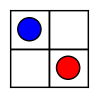

Computing bracket form for Normal ruleset...
Using depth limit: 5
{0|0}

AllSmall Ruleset Bracket Form:
Board visualization:


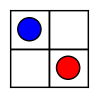

Computing bracket form for AllSmall ruleset...
Using depth limit: 5
{0|0}


In [10]:
import matplotlib.pyplot as plt
import numpy as np
import warnings

# Constants
ORTHOGONAL_DIRECTIONS = [(-1, 0), (1, 0), (0, -1), (0, 1)]  # No diagonals

# Original game functions
def parse_board(board_str):
    """Convert board string to a 2D list representation and validate legality."""
    rows = board_str.split("|")
    row_lengths = {len(row) for row in rows}
    
    if len(row_lengths) > 1:
        raise ValueError("Invalid board: Rows must all be the same length.")
        
    allowed_chars = {"O", "X", "*"}
    for row in rows:
        if not set(row).issubset(allowed_chars):
            raise ValueError("Invalid board: Only 'O', 'X', and '*' are allowed.")
            
    return [list(row) for row in rows]
    
def get_groups(board, player):
    """Find all groups (connected components) of the given player."""
    groups = []
    visited = set()
    rows, cols = len(board), len(board[0])

    def dfs(r, c, group):
        if (r, c) in visited or board[r][c] != player:
            return
        visited.add((r, c))
        group.append((r, c))
        for dr, dc in ORTHOGONAL_DIRECTIONS:
            nr, nc = r + dr, c + dc
            if 0 <= nr < rows and 0 <= nc < cols:
                dfs(nr, nc, group)

    for r in range(rows):
        for c in range(cols):
            if board[r][c] == player and (r, c) not in visited:
                group = []
                dfs(r, c, group)
                groups.append(group)
    
    return groups

def get_valid_moves(board, group):
    """Get all empty spaces orthogonally adjacent to a group."""
    rows, cols = len(board), len(board[0])
    moves = set()

    for r, c in group:
        for dr, dc in ORTHOGONAL_DIRECTIONS:
            nr, nc = r + dr, c + dc
            if 0 <= nr < rows and 0 <= nc < cols and board[nr][nc] == "*":
                moves.add((nr, nc))
    
    return list(moves)

def get_isolated_squares(board, player):
    """Find all isolated empty squares where the player can place a piece."""
    rows, cols = len(board), len(board[0])
    isolated = []
    for r in range(rows):
        for c in range(cols):
            if board[r][c] != "*":
                continue  # Not an empty square

            has_adjacent = any(
                0 <= r+dr < rows and 0 <= c+dc < cols and board[r+dr][c+dc] == player
                for dr, dc in ORTHOGONAL_DIRECTIONS
            )
            if not has_adjacent:  # If no adjacent pieces, it's isolated
                isolated.append((r, c))

    return isolated

# Bracket form computation functions
def compute_bracket_form(board, use_allsmall=False, max_depth=None, current_depth=0, memo=None):
    """
    Compute the bracket form for a given board position.
    
    Args:
        board: 2D list representing the current board state
        use_allsmall: Whether to use the AllSmall ruleset
        max_depth: Maximum recursion depth (None for unlimited)
        current_depth: Current recursion depth
        memo: Dictionary for memoization
    """
    if memo is None:
        memo = {}
    
    # Convert board to a string for memoization
    board_key = board_to_key(board)
    
    if board_key in memo:
        return memo[board_key]
    
    # Check depth limit
    if max_depth is not None and current_depth >= max_depth:
        warnings.warn(f"Reached maximum depth of {max_depth}. Bracket form is incomplete.")
        return "{DEPTH_LIMIT}"
    
    # Get Left player (O) options
    left_options = []
    for new_board in get_player_moves(board, "O", use_allsmall):
        option_value = compute_bracket_form(new_board, use_allsmall, max_depth, 
                                            current_depth + 1, memo)
        left_options.append(option_value)
    
    # Get Right player (X) options
    right_options = []
    for new_board in get_player_moves(board, "X", use_allsmall):
        option_value = compute_bracket_form(new_board, use_allsmall, max_depth, 
                                            current_depth + 1, memo)
        right_options.append(option_value)
    
    # Remove duplicates (same positions)
    left_options = list(set(left_options))
    right_options = list(set(right_options))
    
    # Build the bracket notation
    bracket_form = "{" + "|".join([",".join(left_options), ",".join(right_options)]) + "}"
    
    # Apply standard CGT simplifications for common values
    if not left_options and not right_options:
        bracket_form = "0"  # Game over, no moves for either player - value 0
    
    # Save result in memo
    memo[board_key] = bracket_form
    
    return bracket_form

def get_player_moves(board, player, use_allsmall=False):
    """Get all possible resulting board states after the player makes a move."""
    all_boards = []
    
    # Get all groups for the player
    groups = get_groups(board, player)
    
    # For each group, create a new board state after expansion
    for group in groups:
        moves = get_valid_moves(board, group)
        if moves:
            # Create a copy of the board
            new_board = [row[:] for row in board]
            
            # Apply the expansion move (fill ALL adjacent empty spaces)
            for r, c in moves:
                new_board[r][c] = player
                
            all_boards.append(new_board)
    
    # If using AllSmall ruleset, also consider isolated placements
    if use_allsmall:
        isolated_squares = get_isolated_squares(board, player)
        for r, c in isolated_squares:
            new_board = [row[:] for row in board]
            new_board[r][c] = player
            all_boards.append(new_board)
    
    return all_boards

def board_to_key(board):
    """Convert a board to a string key for memoization."""
    return '|'.join([''.join(row) for row in board])

def format_bracket_form(bracket_form):
    """Format the bracket form for display, ensuring proper syntax."""
    # Handle special cases
    if bracket_form in ["0", "{DEPTH_LIMIT}"]:
        return bracket_form
    
    # Remove outer brackets
    if bracket_form.startswith("{") and bracket_form.endswith("}"):
        content = bracket_form[1:-1]
    else:
        return bracket_form  # Return as is if not in bracket form
    
    # Split at the pipe character
    parts = content.split("|")
    if len(parts) != 2:
        return bracket_form  # Return as is if not properly formatted
    
    left_part, right_part = parts
    
    # Process left options
    left_options = []
    if left_part:
        left_options = [opt.strip() for opt in left_part.split(",") if opt.strip()]
    
    # Process right options
    right_options = []
    if right_part:
        right_options = [opt.strip() for opt in right_part.split(",") if opt.strip()]
    
    # Recreate the bracket form with proper formatting
    formatted = "{" + "|".join([",".join(left_options), ",".join(right_options)]) + "}"
    
    return formatted

def visualize_board_array(board):
    """Visualize a 2D board array using matplotlib."""
    rows, cols = len(board), len(board[0])
    color_map = {"O": "blue", "X": "red", "*": "white"}
    
    fig, ax = plt.subplots(figsize=(cols * 0.5, rows * 0.5))
    
    # Setup grid
    ax.set_xticks(np.arange(0, cols + 1, 1))
    ax.set_yticks(np.arange(0, rows + 1, 1))
    ax.grid(which="both", color="black", linestyle='-', linewidth=1)
    ax.set_xticklabels([])
    ax.set_yticklabels([])
    ax.tick_params(which="both", bottom=False, left=False)
    
    # Draw grid squares
    for r in range(rows):
        for c in range(cols):
            ax.add_patch(plt.Rectangle((c, rows - r - 1), 1, 1, edgecolor="black", facecolor="white"))
    
    # Draw pieces
    for r in range(rows):
        for c in range(cols):
            if board[r][c] in color_map and board[r][c] != "*":
                ax.add_patch(plt.Circle((c + 0.5, rows - r - 0.5), 0.3, 
                                        color=color_map[board[r][c]], ec="black"))
    plt.show()

def analyze_game_position(board_str, use_allsmall=False, max_depth=None):
    """Analyze a game position and display its bracket form."""
    # Parse the board
    board = parse_board(board_str)
    
    print("Board visualization:")
    visualize_board_array(board)
    
    print(f"Computing bracket form for {'AllSmall' if use_allsmall else 'Normal'} ruleset...")
    if max_depth:
        print(f"Using depth limit: {max_depth}")
    else:
        print("No depth limit (may take a long time for complex positions)")
        
    # Compute the bracket form
    bracket_form = compute_bracket_form(board, use_allsmall, max_depth)
    
    # Format for consistency
    formatted = format_bracket_form(bracket_form)
    
    return formatted

# Example usage
if __name__ == "__main__":
    # Example 2x2 board
    board_str = "O*|*X"
    
    print("Normal Ruleset Bracket Form:")
    result = analyze_game_position(board_str, use_allsmall=False, max_depth=5)
    print(result)
    
    print("\nAllSmall Ruleset Bracket Form:")
    result = analyze_game_position(board_str, use_allsmall=True, max_depth=5)
    print(result)


In [11]:
def visualize_board_array(board, group_cells=None, expansion_cells=None):
    """
    Visualize the board array with optional highlighting for groups and expansions.
    
    Parameters:
    - board: Array representation of the board
    - group_cells: List of (row, col) tuples for the group to highlight (blue)
    - expansion_cells: List of (row, col) tuples for expansion cells (yellow)
    """
    rows, cols = len(board), len(board[0])
    color_map = {"O": "blue", "X": "red", "*": "white"}

    fig, ax = plt.subplots(figsize=(cols * 0.5, rows * 0.5))  # Smaller overall figure
    
    # Fixing grid line positions
    ax.set_xticks(np.arange(0, cols + 1, 1))
    ax.set_yticks(np.arange(0, rows + 1, 1))
    ax.grid(which="both", color="black", linestyle='-', linewidth=1)
    ax.set_xticklabels([])
    ax.set_yticklabels([])
    ax.tick_params(which="both", bottom=False, left=False)

    # Draw grid squares with highlighting
    for r in range(rows):
        for c in range(cols):
            cell_color = "white"
            if group_cells and (r, c) in group_cells:
                cell_color = "lightblue"  # Highlight group in lightblue
            if expansion_cells and (r, c) in expansion_cells:
                cell_color = "yellow"  # Highlight expansion in yellow
            ax.add_patch(plt.Rectangle((c, rows - r - 1), 1, 1, edgecolor="black", facecolor=cell_color))

    # Draw circular beads for pieces
    for r in range(rows):
        for c in range(cols):
            if board[r][c] in color_map and board[r][c] != "*":
                ax.add_patch(plt.Circle((c + 0.5, rows - r - 0.5), 0.3, color=color_map[board[r][c]], ec="black"))

    plt.show()

def visualize_board(board_str, group_cells=None, expansion_cells=None):
    """
    Visualize the string board with optional highlighting for groups and expansions.
    
    Parameters:
    - board_str: String representation of the board
    - group_cells: List of (row, col) tuples for the group to highlight (blue)
    - expansion_cells: List of (row, col) tuples for expansion cells (yellow)
    """
    board = [list(row) for row in board_str.split("|")]
    rows, cols = len(board), len(board[0])
    color_map = {"O": "blue", "X": "red", "*": "white"}

    fig, ax = plt.subplots(figsize=(cols * 0.5, rows * 0.5))  # Smaller overall figure
    
    # Fixing grid line positions
    ax.set_xticks(np.arange(0, cols + 1, 1))
    ax.set_yticks(np.arange(0, rows + 1, 1))
    ax.grid(which="both", color="black", linestyle='-', linewidth=1)
    ax.set_xticklabels([])
    ax.set_yticklabels([])
    ax.tick_params(which="both", bottom=False, left=False)

    # Draw grid squares with highlighting
    for r in range(rows):
        for c in range(cols):
            cell_color = "white"
            if group_cells and (r, c) in group_cells:
                cell_color = "lightblue"  # Highlight group in lightblue
            if expansion_cells and (r, c) in expansion_cells:
                cell_color = "yellow"  # Highlight expansion in yellow
            ax.add_patch(plt.Rectangle((c, rows - r - 1), 1, 1, edgecolor="black", facecolor=cell_color))

    # Draw circular beads for pieces
    for r in range(rows):
        for c in range(cols):
            if board[r][c] in color_map and board[r][c] != "*":
                ax.add_patch(plt.Circle((c + 0.5, rows - r - 0.5), 0.3, color=color_map[board[r][c]], ec="black"))

    plt.show()

def play_game(board_str):
    """Main game loop."""
    board = parse_board(board_str)
    visualize_board_array(board)  # Initial board without highlighting
    players = ["O", "X"]
    turn = 0  # O starts

    while True:
        current_player = players[turn]
        print(f"Player {current_player}'s turn:")
        
        groups = get_groups(board, current_player)
        valid_moves = []

        # Collect all valid moves for each group
        for group in groups:
            moves = get_valid_moves(board, group)
            if moves:
                valid_moves.append((group, moves))
        
        if not valid_moves:
            print(f"Player {current_player} has no moves left! {players[1-turn]} wins!")
            break  # Game over

        # Show available moves
        for i, (group, moves) in enumerate(valid_moves, start=1):
            print(f"{i}. Group at {group} → Expand to {moves}")

        while True:  # Keep asking until a valid move is chosen
            try:
                choice = int(input("Choose a group (1, 2, ...): ")) - 1
                if 0 <= choice < len(valid_moves):
                    break  # Exit loop if the choice is valid
                elif choice == -1:
                    break
                else:
                    print(f"Invalid choice! Please enter a number between 1 and {len(valid_moves)}.")
            except ValueError:
                print("Invalid input! Please enter a valid integer.")
        
        if choice == -1:
            print("why end so fast :(")
            break
        
        if 0 <= choice < len(valid_moves):
            chosen_group, expansion_cells = valid_moves[choice]
            
            # First visualization: Show the chosen group highlighted
            visualize_board_array(board, group_cells=chosen_group)
            
            # Apply the move
            apply_move(board, chosen_group)
            
            # Second visualization: Show the board after move with BOTH original group 
            # and expansion cells highlighted
            visualize_board_array(board, group_cells=chosen_group, expansion_cells=expansion_cells)
        
        # Finally show the updated board without highlighting for the next player's turn
        visualize_board_array(board)
        
        turn = 1 - turn  # Switch players


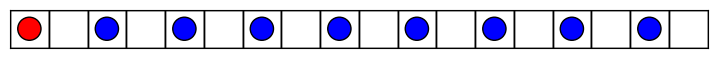

Player O's turn:
1. Group at [(0, 2)] → Expand to [(0, 1), (0, 3)]
2. Group at [(0, 4)] → Expand to [(0, 3), (0, 5)]
3. Group at [(0, 6)] → Expand to [(0, 7), (0, 5)]
4. Group at [(0, 8)] → Expand to [(0, 7), (0, 9)]
5. Group at [(0, 10)] → Expand to [(0, 9), (0, 11)]
6. Group at [(0, 12)] → Expand to [(0, 13), (0, 11)]
7. Group at [(0, 14)] → Expand to [(0, 13), (0, 15)]
8. Group at [(0, 16)] → Expand to [(0, 15), (0, 17)]


Choose a move:  0


why end so fast :(


In [12]:
# board_str = '****|****|****'
def game_weird(n):
    """
    Returns a LaTeX-formatted string like 'X*O*O⋯O*' with n O's in the middle, without math mode ($).
    """
    return "X*" + "O*" * n

play_game_allsmall(game_weird(8))


Board visualization:


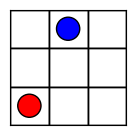

Computing bracket form for Normal ruleset...
No depth limit (may take a long time for complex positions)
{{{0|}|{{0|0}|{0|0}}}|{{{0|0}|{0|0}}|{{0|0}|{0|0}}}}


In [18]:
# board_str = 'X*O*O'
# board_str = 'X*O*'
# for i in range(7,9):
    # board_str=game_weird(i)
board_str = '*O*|***|X**'
result = analyze_game_position(board_str,use_allsmall=False)
print(result)

In [18]:
from itertools import product

def generate_strings(n):
    chars = ['*', 'O', 'X']
    lis = [''.join(p) for p in product(chars, repeat=n)]
    # for s in lis:
        # print(s)
    return lis

# Example usage:
lis = generate_strings(3)  # Change 3 to any value of n
print(lis)

['***', '**O', '**X', '*O*', '*OO', '*OX', '*X*', '*XO', '*XX', 'O**', 'O*O', 'O*X', 'OO*', 'OOO', 'OOX', 'OX*', 'OXO', 'OXX', 'X**', 'X*O', 'X*X', 'XO*', 'XOO', 'XOX', 'XX*', 'XXO', 'XXX']


In [19]:
import random

def generate_random_strings(n, count=10):
    chars = ['*', 'O', 'X']
    lis = [''.join(random.choices(chars, k=n)) for _ in range(count)]
    for s in lis:
        print(s)
    return lis

# Example usage:
lis = generate_random_strings(4)  # Replace 5 with your desired length

*OOO
OOOO
O*O*
OXO*
O*OO
X*O*
*XOX
XXOX
XXX*
**XX


Board visualization:


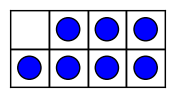

Computing bracket form for Normal ruleset...
No depth limit (may take a long time for complex positions)
{0|}
Board visualization:


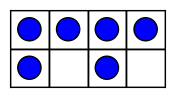

Computing bracket form for Normal ruleset...
No depth limit (may take a long time for complex positions)
{0|}
Board visualization:


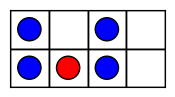

Computing bracket form for Normal ruleset...
No depth limit (may take a long time for complex positions)
{0,{0|}|{0|}}
Board visualization:


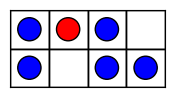

Computing bracket form for Normal ruleset...
No depth limit (may take a long time for complex positions)
{0,{0|}|{0|}}
Board visualization:


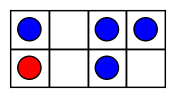

Computing bracket form for Normal ruleset...
No depth limit (may take a long time for complex positions)
{{0|{0|}},0|{0,{0|}|{0|}}}
Board visualization:


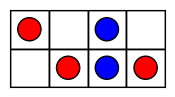

Computing bracket form for Normal ruleset...
No depth limit (may take a long time for complex positions)
{{|0}|{0|0},{{|0}|0}}
Board visualization:


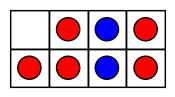

Computing bracket form for Normal ruleset...
No depth limit (may take a long time for complex positions)
{|0}
Board visualization:


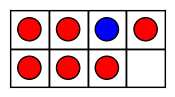

Computing bracket form for Normal ruleset...
No depth limit (may take a long time for complex positions)
{|0}
Board visualization:


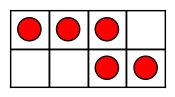

Computing bracket form for Normal ruleset...
No depth limit (may take a long time for complex positions)
{|0}


In [20]:
for i in range(len(lis)-1):
    board_str=lis[i]+'|'+lis[i+1]
    result = analyze_game_position(board_str,use_allsmall=False)
    print(result)

Board visualization:


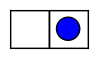

Computing bracket form for Normal ruleset...
No depth limit (may take a long time for complex positions)
{0|}


In [21]:
result = analyze_game_position('*O', use_allsmall=False)
print(result)